[![Wiki](https://img.shields.io/badge/-Wiki-blue?style=flat-square&logo=github)](./wiki/05-Effect-of-W-D-C-Variants.md)
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neurovium/CorticalBlueprintRNN/blob/main/StatisticalAnalysis/The_Effect_of_w_d_and_c_variants%20.ipynb)

*Effect of W, D, C variants — combined (earlier version of the per-task notebooks). See [wiki 05 — Effect of W, D, C](./wiki/05-Effect-of-W-D-C-Variants.md).*

# Import Libraries

In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
import itertools
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import itertools
from statsmodels.stats.multitest import multipletests

# Load dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [ ]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
   creating: /content/data/simu/
   creating: /content/data/simu/5_6_8_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+  
  inflating: /content/data/simu/.DS_Store  
  inflating: /content/data/__MACOSX/simu/._.DS_Store  
   creating: /content/data/simu/5_6_8_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-corr/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr  
   creating: /content/data/simu/5_3_4_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision/
  inflating: /cont

In [ ]:
print(os.listdir("/content/data/simu"))

['6_6_2_sttc-precision_sign+', '6_6_2_sttc-precision', '5_6_8_sttc-corr_sign+', '5_6_8_sttc-precision_sign+', '.DS_Store', '6_6_2_sttc-corr', '5_3_4_sttc-corr', '6_6_2_sttc-corr_sign+', 'plotting.ipynb', '5_3_4_sttc-corr_sign+', '5_6_8_sttc-corr', '5_3_4_sttc-precision_sign+', '5_3_4_sttc-precision', 'rcc.ipynb', '5_6_8_sttc-precision']


## In the same scan and field

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'
print(folder_name)

# task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
# task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
# task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

/content/data/simu/6_6_2_sttc-corr


In [ ]:
task1_folder_dir = f'{folder_name}/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df.to_csv("combined_dataset.csv", index=False)



print(final_df.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  1.000000    -0.051992    0.472607  0.801269   
1                  1      W*D*C  1.000000     0.061169    0.559405  1.915917   
2                  2      W*D*C  0.694531    -0.093343    0.504541  2.027120   
3                  3      W*D*C  0.762500    -0.079137    0.397618  2.166722   
4                  4      W*D*C  1.000000     0.010076    0.497746  0.601358   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.254178  0.053901             1.000000         0.051040  
1        2.491821  0.090934             1.000000         0.086108  
2        2.247430  1.549415             0.885547         1.138137  
3        1.947331  1.239510             0.872656         0.935718  
4        1.572843  0.056338             1.000000         0.051276  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df["w_variant"] = final_df["model_name"].apply(classify_variant)


In [ ]:
scaler = MinMaxScaler()
final_df["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])


In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,1.000000,-0.051992,0.472607,0.801269,2.254178,0.000831,1.000000,0.000729,w*
1,1,W*D*C,1.000000,0.061169,0.559405,1.915917,2.491821,0.001834,1.000000,0.001602,w*
2,2,W*D*C,0.694531,-0.093343,0.504541,2.027120,2.247430,0.041319,0.885547,0.027765,w*
3,3,W*D*C,0.762500,-0.079137,0.397618,2.166722,1.947331,0.032929,0.872656,0.022731,w*
4,4,W*D*C,1.000000,0.010076,0.497746,0.601358,1.572843,0.000897,1.000000,0.000735,w*


# Compare only two models

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

In [ ]:
def are_models_significantly_different(df, model1, model2, metric):
  res = kruskal(
    df.query(f"model_name == '{model1}'")[metric],
    df.query(f"model_name == '{model2}'")[metric],
  )

  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
# are_models_significantly_different(final_df, 'WD*C*', 'W*D*C*', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C*', 'W*D*C*', metric)}')

accuracy : (True, np.float64(5.893022870607708e-05))
assortivity : (True, np.float64(3.277513413697066e-06))
entropy : (False, np.float64(0.5517753193316655))
loss : (True, np.float64(3.735782152219861e-06))
modularity : (True, np.float64(2.1678347713942432e-05))
smallWorldness : (True, np.float64(0.045316297344651826))
validation_accuracy : (True, np.float64(2.018198086243426e-05))
validation_loss : (False, np.float64(0.08341508335601137))


In [ ]:
# are_models_significantly_different(final_df, 'W*D*C*', 'W!D*C*', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'W*D*C*', 'W!D*C*', metric)}')

accuracy : (False, np.float64(0.514764265007895))
assortivity : (False, np.float64(0.6849253186565256))
entropy : (False, np.float64(0.3577279701934136))
loss : (False, np.float64(0.4327745949916697))
modularity : (False, np.float64(0.465174803618463))
smallWorldness : (False, np.float64(0.4327745949916697))
validation_accuracy : (False, np.float64(0.15207808079296853))
validation_loss : (False, np.float64(0.6263280630826004))


In [ ]:
# are_models_significantly_different(final_df, 'WD*C', 'W!D*C', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C', 'W!D*C', metric)}')

accuracy : (True, np.float64(1.1479153652934516e-06))
assortivity : (True, np.float64(6.301848221392254e-08))
entropy : (True, np.float64(6.301848221392254e-08))
loss : (True, np.float64(2.0624711744910948e-07))
modularity : (False, np.float64(0.481867368283708))
smallWorldness : (True, np.float64(0.02844765254397576))
validation_accuracy : (True, np.float64(1.0776822986690779e-08))
validation_loss : (True, np.float64(1.1465546070186638e-07))


# Compare the effect of w_variant

In [ ]:
def are_w_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("w_variant == 'w'")[metric],
    df.query("w_variant == 'w*'")[metric],
    df.query("w_variant == 'w!'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue


In [ ]:
are_w_variants_significantly_different(final_df, "smallWorldness")

(True, np.float64(6.868785561877757e-06))

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

for metric in metrics:
  print(f'{metric} : {are_w_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(9.290073444017737e-27))
assortivity : (True, np.float64(4.784229190923266e-08))
entropy : (True, np.float64(0.000610913410185776))
loss : (True, np.float64(0.003607282740137304))
modularity : (False, np.float64(0.14467772355962497))
smallWorldness : (True, np.float64(6.868785561877757e-06))
validation_accuracy : (True, np.float64(1.1642942725493827e-26))
validation_loss : (True, np.float64(0.0032606662442299936))


In [ ]:
def how_w_variants_are_different(df, metric):
    groups = df["w_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("w_variant == @g1")[metric].dropna().astype(float)
        y = df.query("w_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")


In [ ]:
for metric in metrics:
  how_w_variants_are_different(final_df, metric)


------ accuracy ------
w* vs w: TRUE, U=6634.5, p=4.46e-21, Median(w*)=1.000, Median(w)=0.627, Mean(w*)=0.955, Mean(w)=0.675, w* > w, P(X>Y)=0.92
w* vs w!: FALSE, U=1174.0, p=0.784, Median(w*)=1.000, Median(w!)=1.000, Mean(w*)=0.955, Mean(w!)=0.956, w* = w!, P(X>Y)=0.49
w vs w!: TRUE, U=521.0, p=5.85e-14, Median(w)=0.627, Median(w!)=1.000, Mean(w)=0.675, Mean(w!)=0.956, w < w!, P(X>Y)=0.11



------ assortivity ------
w* vs w: TRUE, U=1824.0, p=7.14e-08, Median(w*)=-0.067, Median(w)=-0.014, Mean(w*)=-0.055, Mean(w)=0.035, w* < w, P(X>Y)=0.25
w* vs w!: FALSE, U=1022.0, p=0.212, Median(w*)=-0.067, Median(w!)=-0.050, Mean(w*)=-0.055, Mean(w!)=-0.048, w* < w!, P(X>Y)=0.43
w vs w!: TRUE, U=3303.0, p=0.000376, Median(w)=-0.014, Median(w!)=-0.050, Mean(w)=0.035, Mean(w!)=-0.048, w > w!, P(X>Y)=0.69



------ entropy ------
w* vs w: TRUE, U=2382.0, p=0.00022, Median(w*)=0.129, Median(w)=0.935, Mean(w*)=0.611, Mean(w)=2.100, w* < w, P(X>Y)=0.33
w* vs w!: TRUE, U=902.0, p=0.0363, Median(w*)=0.1

# Effect of sign constraint on W

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = True # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_1 = f'/content/data/simu/{base}'
print(folder_name_1)

/content/data/simu/6_6_2_sttc-corr_sign+


In [ ]:
task1_folder_dir_sign = f'{folder_name_1}/Task1/'
task1_folder_dir_sign

'/content/data/simu/6_6_2_sttc-corr_sign+/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_sign, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_sign = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_sign.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_sign.to_csv("combined_dataset_1.csv", index=False)

print(final_df_sign.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.640039    -0.331500    0.253355  0.260738   
1                  1      W*D*C  1.000000     0.185131    0.513902  0.243979   
2                  2      W*D*C  1.000000     0.059382    0.480339  0.280391   
3                  3      W*D*C  1.000000     0.036822    0.483748  0.294450   
4                  4      W*D*C  0.628711    -0.249219    0.249962  0.099865   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        3.244314  0.674887             0.623438         0.663207  
1        2.754349  0.050037             1.000000         0.046491  
2        1.273240  0.022915             1.000000         0.021867  
3        2.505805  0.028237             1.000000         0.027346  
4        2.828275  0.653000             0.623438         0.612249  


In [ ]:
scaler = MinMaxScaler()
final_df_sign["w_variant"] = final_df_sign["model_name"].apply(classify_variant)
final_df_sign["loss"] = scaler.fit_transform(final_df_sign[["loss"]])
final_df_sign['validation_loss'] = scaler.fit_transform(final_df_sign[["validation_loss"]])

In [ ]:
final_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,0.640039,-0.331500,0.253355,0.260738,3.244314,0.048844,0.623438,0.048078,w*
1,1,W*D*C,1.000000,0.185131,0.513902,0.243979,2.754349,0.002303,1.000000,0.002139,w*
2,2,W*D*C,1.000000,0.059382,0.480339,0.280391,1.273240,0.000283,1.000000,0.000305,w*
3,3,W*D*C,1.000000,0.036822,0.483748,0.294450,2.505805,0.000679,1.000000,0.000713,w*
4,4,W*D*C,0.628711,-0.249219,0.249962,0.099865,2.828275,0.047213,0.623438,0.044282,w*


In [ ]:
non_biological_metrics = ['accuracy', 'loss', 'validation_accuracy', 'validation_loss']
biological_metrics = ['assortivity', 'entropy', 'modularity', 'smallWorldness']

In [ ]:
final_df['sign'] = False
final_df_sign['sign'] = True

In [ ]:
combined_df_sign = pd.concat([final_df, final_df_sign], ignore_index=True)

combined_df_sign = combined_df_sign.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign
0,0,W,0.617188,-0.016950,0.085761,5.657654,0.997841,0.330169,0.618359,0.302073,w,False
1,0,W,0.238477,NaN,NaN,NaN,NaN,NaN,0.251953,NaN,w,True
2,0,W!D*C,1.000000,0.000551,0.470566,0.739893,2.225924,0.001798,1.000000,0.001418,w!,False
3,0,W!D*C,0.700391,-0.113440,0.217328,0.122585,2.630536,0.038035,0.628906,0.042183,w!,True
4,0,W!D*C*,1.000000,-0.045075,0.092286,1.102208,1.019185,0.399504,1.000000,0.369016,w!,False


In [ ]:
combined_df_sign.shape

(440, 12)

In [ ]:
def is_sign_constraint_significantly_different(df, metric):
  res = kruskal(
    df.query("sign == True")[metric],
    df.query("sign == False")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_sign_constraint_is_different(df, metric, variant):
  groups = df["sign"].unique()
  pairs = list(itertools.combinations(groups, 2))

  print(f"\n------ {metric}--- {variant} ------")
  for g1, g2 in pairs:
      x = df.query("sign == @g1")[metric].dropna().astype(float)
      y = df.query("sign == @g2")[metric].dropna().astype(float)

      u, p = mannwhitneyu(x, y, alternative='two-sided')

      median_x, median_y = np.median(x), np.median(y)
      mean_x, mean_y = np.mean(x), np.mean(y)

      n1, n2 = len(x), len(y)
      prob_superiority = u / (n1 * n2)  # P(X > Y)

      direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

      signif = "TRUE" if p < 0.05 else "FALSE"
      print(
          f"{'sign constraint' if g1 else 'no sign'} vs {'sign constraint' if g2 else 'no sign'}: {signif}, "
          f"U={u:.1f}, p={p:.3g}, "
          f"Median({'sign constraint' if g1 else 'no sign'} )={median_x:.3f}, Median({'sign constraint' if g2 else 'no sign'})={median_y:.3f}, "
          f"Mean({'sign constraint' if g1 else 'no sign'} )={mean_x:.3f}, Mean({'sign constraint' if g2 else 'no sign'})={mean_y:.3f}, "
          f"{'sign constraint' if g1 else 'no sign'} {direction} {'sign constraint' if g2 else 'no sign'} , P(X>Y)={prob_superiority:.2f}"
      )
  print("\n")

In [ ]:
for metric in non_biological_metrics:
    print(f'W - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (False, np.float64(nan))
W* - accuracy : (False, np.float64(nan))
W! - accuracy : (False, np.float64(nan))

W - loss : (False, np.float64(nan))
W* - loss : (False, np.float64(nan))
W! - loss : (False, np.float64(nan))

W - validation_accuracy : (False, np.float64(nan))
W* - validation_accuracy : (False, np.float64(nan))
W! - validation_accuracy : (False, np.float64(nan))

W - validation_loss : (False, np.float64(nan))
W* - validation_loss : (False, np.float64(nan))
W! - validation_loss : (False, np.float64(nan))



/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

In [ ]:
for metric in non_biological_metrics:
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w'], metric, 'w')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric, 'w*')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric, 'w!')


------ accuracy--- w ------


TypeError: unsupported object type: <class 'function'>

#### Biological Metrics

In [ ]:
for metric in biological_metrics:
  print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w*")], metric)}')
  print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w!")], metric)}')

W* - assortivity : (False, np.float64(nan))
W! - assortivity : (False, np.float64(nan))
W* - entropy : (False, np.float64(nan))
W! - entropy : (False, np.float64(nan))
W* - modularity : (False, np.float64(nan))
W! - modularity : (False, np.float64(nan))
W* - smallWorldness : (False, np.float64(nan))
W! - smallWorldness : (False, np.float64(nan))


/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

In [ ]:
for metric in biological_metrics:
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric, 'w*')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric, 'w!')


------ assortivity--- w* ------


TypeError: unsupported object type: <class 'function'>

# Correlation matrix vs Presicion matrix effect on W




In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = True # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/6_6_2_sttc-precision


In [ ]:
task1_folder_dir_precision = f'{folder_name_2}/Task1/'
task1_folder_dir_precision

'/content/data/simu/6_6_2_sttc-precision/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_precision, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_precision = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_precision.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_precision.to_csv("combined_dataset_1.csv", index=False)

print(final_df_precision.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C   1.00000    -0.042590    0.521784  0.833859   
1                  1      W*D*C   1.00000     0.074159    0.499620  2.110446   
2                  2      W*D*C   1.00000     0.062079    0.478886  0.558211   
3                  3      W*D*C   1.00000     0.076430    0.497123  2.091828   
4                  4      W*D*C   0.64043    -0.142572    0.336928  2.065610   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.276312  0.146480             1.000000         0.122949  
1        1.980092  0.162948             1.000000         0.135651  
2        1.634721  0.046259             1.000000         0.043218  
3        2.217784  0.142850             1.000000         0.116731  
4        1.933398  2.303698             0.747656         1.411339  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df_precision["w_variant"] = final_df_precision["model_name"].apply(classify_variant)

In [ ]:
scaler = MinMaxScaler()
final_df_precision["loss"] = scaler.fit_transform(final_df_precision[["loss"]])
final_df_precision['validation_loss'] = scaler.fit_transform(final_df_precision[["validation_loss"]])

In [ ]:
final_df_precision.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,1.00000,-0.042590,0.521784,0.833859,2.276312,0.003207,1.000000,0.002443,w*
1,1,W*D*C,1.00000,0.074159,0.499620,2.110446,1.980092,0.003641,1.000000,0.002754,w*
2,2,W*D*C,1.00000,0.062079,0.478886,0.558211,1.634721,0.000569,1.000000,0.000487,w*
3,3,W*D*C,1.00000,0.076430,0.497123,2.091828,2.217784,0.003112,1.000000,0.002290,w*
4,4,W*D*C,0.64043,-0.142572,0.336928,2.065610,1.933398,0.059994,0.747656,0.034049,w*


In [ ]:
final_df['matrix'] = 'sttc'
final_df_precision['matrix'] = 'precision'

combined_df_matrix = pd.concat([final_df, final_df_precision], ignore_index=True)

combined_df_matrix = combined_df_matrix.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_matrix.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix
0,0,W,0.617188,-0.016950,0.085761,5.657654,0.997841,0.330169,0.618359,0.302073,w,False,sttc
1,0,W,0.623828,-0.042034,0.087880,5.605302,0.990753,0.319735,0.618750,0.296778,w,NaN,precision
2,0,W!D*C,1.000000,0.000551,0.470566,0.739893,2.225924,0.001798,1.000000,0.001418,w!,False,sttc
3,0,W!D*C,1.000000,0.035495,0.474811,0.742379,1.298809,0.000257,1.000000,0.000230,w!,NaN,precision
4,0,W!D*C*,1.000000,-0.045075,0.092286,1.102208,1.019185,0.399504,1.000000,0.369016,w!,False,sttc


In [ ]:
def is_matrix_variant_significantly_different(df, metric):
  res = kruskal(
    df.query("matrix == 'sttc'")[metric],
    df.query("matrix == 'precision'")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_matrix_variants_are_different(df, metric, variant):
    groups = df["matrix"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} --- {variant} ------")
    for g1, g2 in pairs:
        x = df.query("matrix == @g1")[metric].dropna().astype(float)
        y = df.query("matrix == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")


In [ ]:
for metric in metrics:
    print(f'W - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (True, np.float64(7.138402457694701e-14))
W* - accuracy : (False, np.float64(0.3727212465073134))
W! - accuracy : (False, np.float64(0.6523816821977682))

W - assortivity : (False, np.float64(0.20472916272823388))
W* - assortivity : (True, np.float64(0.00012467075088824732))
W! - assortivity : (True, np.float64(0.049647229657456375))

W - entropy : (False, np.float64(0.4832786498849616))
W* - entropy : (False, np.float64(0.7728299926844727))
W! - entropy : (False, np.float64(0.24041683705469835))

W - loss : (False, np.float64(0.16996204798233921))
W* - loss : (False, np.float64(0.10316382199595624))
W! - loss : (False, np.float64(0.08072500999039321))

W - modularity : (True, np.float64(0.033088324168648424))
W* - modularity : (False, np.float64(0.48513406764260003))
W! - modularity : (False, np.float64(0.38122147227266))

W - smallWorldness : (False, np.float64(0.15113058866536205))
W* - smallWorldness : (False, np.float64(0.05087962559629043))
W! - smallWorldness : (F

In [ ]:
for metric in metrics:
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric, 'w')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric, 'w*')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric, 'w!')


------ accuracy --- w ------
sttc vs precision: TRUE, U=11223.5, p=7.19e-14, Median(sttc)=0.627, Median(precision)=0.621, Mean(sttc)=0.675, Mean(precision)=0.645, sttc > precision, P(X>Y)=0.78



------ accuracy --- w* ------
sttc vs precision: FALSE, U=1694.5, p=0.375, Median(sttc)=1.000, Median(precision)=1.000, Mean(sttc)=0.955, Mean(precision)=0.966, sttc = precision, P(X>Y)=0.47



------ accuracy --- w! ------
sttc vs precision: FALSE, U=831.0, p=0.658, Median(sttc)=1.000, Median(precision)=1.000, Mean(sttc)=0.956, Mean(precision)=0.963, sttc = precision, P(X>Y)=0.52



------ assortivity --- w ------
sttc vs precision: FALSE, U=6518.0, p=0.205, Median(sttc)=-0.014, Median(precision)=-0.009, Mean(sttc)=0.035, Mean(precision)=0.054, sttc < precision, P(X>Y)=0.45



------ assortivity --- w* ------
sttc vs precision: TRUE, U=2531.0, p=0.000126, Median(sttc)=-0.067, Median(precision)=-0.101, Mean(sttc)=-0.055, Mean(precision)=-0.079, sttc > precision, P(X>Y)=0.70



------ assortiv

# Compare the effect of neuron count

In [ ]:
session, scan, field = 5, 6, 8

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/5_6_8_sttc-corr


In [ ]:
task1_folder_dir_568 = f'{folder_name_2}/Task1/'
task1_folder_dir_568

'/content/data/simu/5_6_8_sttc-corr/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_568, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_568 = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_568.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_568.to_csv("combined_dataset_1.csv", index=False)

print(final_df_568.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C       1.0    -0.156655    0.595788  1.053133   
1                  1      W*D*C       1.0     0.223168    0.583930  1.768853   
2                  2      W*D*C       1.0     0.173504    0.592833  1.147186   
3                  3      W*D*C       1.0     0.102941    0.625822  2.046564   
4                  4      W*D*C       1.0    -0.180520    0.615597  1.007833   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.650168  0.033730                  1.0         0.031473  
1        2.262323  0.085000                  1.0         0.080683  
2        2.396407  0.066245                  1.0         0.062926  
3        2.415353  0.256399                  1.0         0.235943  
4        2.349016  0.019043                  1.0         0.017291  


In [ ]:
session, scan, field = 5, 3, 4

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/5_3_4_sttc-corr


In [ ]:
task1_folder_dir_534 = f'{folder_name_2}/Task1/'
task1_folder_dir_534

'/content/data/simu/5_3_4_sttc-corr/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_534, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_534 = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_534.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_534.to_csv("combined_dataset_1.csv", index=False)

print(final_df_534.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.777930    -0.173498    0.602954  3.141714   
1                  1      W*D*C  0.755859     0.150889    0.628134  3.036219   
2                  2      W*D*C  1.000000    -0.127765    0.645759  2.697506   
3                  3      W*D*C  1.000000    -0.098826    0.615256  2.659157   
4                  4      W*D*C  1.000000     0.336267    0.580071  2.900176   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.020549  0.917393             1.000000         0.651179  
1        1.521436  0.735113             0.738281         0.658513  
2        1.481063  0.046804             1.000000         0.043395  
3        1.688839  0.087450             1.000000         0.083395  
4        0.954364  0.088310             1.000000         0.080835  


In [ ]:
scaler = MinMaxScaler()
final_df_568["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df_568['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])
final_df_534["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df_534['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])

In [ ]:
final_df['neuron'] = 312
final_df_568['neuron'] = 160
final_df_534['neuron'] = 70

combined_df_neuron = pd.concat([final_df, final_df_568, final_df_534], ignore_index=True)

combined_df_neuron = combined_df_neuron.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_neuron.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,neuron
0,0,W,0.617188,-0.016950,0.085761,5.657654,0.997841,0.330169,0.618359,0.302073,312
1,0,W,0.624609,-0.053194,0.112159,5.700906,0.939760,0.330169,0.628906,0.302073,160
2,0,W,0.622266,-0.040578,0.199427,0.050396,0.775444,0.330169,0.621875,0.302073,70
3,0,W!D*C,1.000000,0.000551,0.470566,0.739893,2.225924,0.001798,1.000000,0.001418,312
4,0,W!D*C,0.877344,0.054078,0.583937,1.500842,2.682200,0.001798,0.874219,0.001418,160


In [ ]:
def is_neuron_count_significantly_different(df, metric):
  res = kruskal(
    df.query("neuron == 312")[metric],
    df.query("neuron == 160")[metric],
    df.query("neuron == 70")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_neuron_count_is_different(df, metric, variant):
  groups = df["neuron"].unique()
  pairs = list(itertools.combinations(groups, 2))

  print(f"\n------ {metric}--- {variant} ------")
  for g1, g2 in pairs:
      x = df.query("neuron == @g1")[metric].dropna().astype(float)
      y = df.query("neuron == @g2")[metric].dropna().astype(float)

      u, p = mannwhitneyu(x, y, alternative='two-sided')

      median_x, median_y = np.median(x), np.median(y)
      mean_x, mean_y = np.mean(x), np.mean(y)

      n1, n2 = len(x), len(y)
      prob_superiority = u / (n1 * n2)  # P(X > Y)

      direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

      signif = "TRUE" if p < 0.05 else "FALSE"
      print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
  print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {is_neuron_count_significantly_different(combined_df_neuron, metric)}')

accuracy : (True, np.float64(0.0004919204431497365))
assortivity : (False, np.float64(0.1848416371756292))
entropy : (True, np.float64(3.61137577548379e-26))
loss : (False, np.float64(1.0))
modularity : (True, np.float64(4.956092981638299e-38))
smallWorldness : (True, np.float64(4.4566522767912e-32))
validation_accuracy : (True, np.float64(2.7152734515902085e-07))
validation_loss : (False, np.float64(1.0))


In [ ]:
for metric in metrics:
  how_neuron_count_is_different(combined_df_neuron, metric, 'neuron')


------ accuracy--- neuron ------
312 vs 160: FALSE, U=24115.5, p=0.947, Median(312)=0.641, Median(160)=0.906, Mean(312)=0.802, Mean(160)=0.822, 312 < 160, P(X>Y)=0.50
312 vs 70: TRUE, U=19765.0, p=0.000285, Median(312)=0.641, Median(70)=1.000, Mean(312)=0.802, Mean(70)=0.884, 312 < 70, P(X>Y)=0.41
160 vs 70: TRUE, U=20319.5, p=0.00128, Median(160)=0.906, Median(70)=1.000, Mean(160)=0.822, Mean(70)=0.884, 160 < 70, P(X>Y)=0.42



------ assortivity--- neuron ------
312 vs 160: FALSE, U=23965.0, p=0.86, Median(312)=-0.036, Median(160)=-0.026, Mean(312)=-0.004, Mean(160)=-0.036, 312 < 160, P(X>Y)=0.50
312 vs 70: FALSE, U=22337.0, p=0.163, Median(312)=-0.036, Median(70)=-0.018, Mean(312)=-0.004, Mean(70)=0.005, 312 < 70, P(X>Y)=0.46
160 vs 70: FALSE, U=21820.0, p=0.0744, Median(160)=-0.026, Median(70)=-0.018, Mean(160)=-0.036, Mean(70)=0.005, 160 < 70, P(X>Y)=0.45



------ entropy--- neuron ------
312 vs 160: TRUE, U=18223.0, p=7.42e-06, Median(312)=0.553, Median(160)=1.042, Mean(312)=1.

# Compare the effect of d_variant

In [ ]:
def classify_d_variant(model):
    if "D*" in model:
        return "d*"
    elif "D" in model:
        return "d"
    else:
        return "nan"

final_df["d_variant"] = final_df["model_name"].apply(classify_d_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,d_variant
0,0,W*D*C,1.000000,-0.051992,0.472607,0.801269,2.254178,0.000831,1.000000,0.000729,w*,d*
1,1,W*D*C,1.000000,0.061169,0.559405,1.915917,2.491821,0.001834,1.000000,0.001602,w*,d*
2,2,W*D*C,0.694531,-0.093343,0.504541,2.027120,2.247430,0.041319,0.885547,0.027765,w*,d*
3,3,W*D*C,0.762500,-0.079137,0.397618,2.166722,1.947331,0.032929,0.872656,0.022731,w*,d*
4,4,W*D*C,1.000000,0.010076,0.497746,0.601358,1.572843,0.000897,1.000000,0.000735,w*,d*


In [ ]:
def are_d_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("d_variant == 'd*'")[metric],
    df.query("d_variant == 'd'")[metric],
    df.query("d_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_d_variants_are_different(df, metric):
    groups = df["d_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("d_variant == @g1")[metric].dropna().astype(float)
        y = df.query("d_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_d_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(1.1397740275391787e-10))
assortivity : (True, np.float64(1.1800079392337903e-07))
entropy : (True, np.float64(8.431924477361792e-19))
loss : (True, np.float64(4.879546200290414e-07))
modularity : (True, np.float64(3.041959922393946e-13))
smallWorldness : (True, np.float64(1.4579311800023226e-05))
validation_accuracy : (True, np.float64(2.6499215211888895e-10))
validation_loss : (True, np.float64(5.00871321182416e-07))


In [ ]:
for metric in metrics:
  how_d_variants_are_different(final_df, metric)


------ accuracy ------
d* vs d: TRUE, U=5799.0, p=5.71e-06, Median(d*)=1.000, Median(d)=0.629, Mean(d*)=0.855, Mean(d)=0.738, d* > d, P(X>Y)=0.69
d* vs nan: TRUE, U=2481.5, p=2.25e-09, Median(d*)=1.000, Median(nan)=0.625, Mean(d*)=0.855, Mean(nan)=0.625, d* > nan, P(X>Y)=0.89
d vs nan: TRUE, U=836.5, p=0.00841, Median(d)=0.629, Median(nan)=0.625, Mean(d)=0.738, Mean(nan)=0.625, d > nan, P(X>Y)=0.70



------ assortivity ------
d* vs d: TRUE, U=6258.0, p=4.13e-08, Median(d*)=-0.031, Median(d)=-0.073, Mean(d*)=0.043, Mean(d)=-0.110, d* > d, P(X>Y)=0.74
d* vs nan: FALSE, U=1356.0, p=0.822, Median(d*)=-0.031, Median(nan)=-0.023, Mean(d*)=0.043, Mean(nan)=-0.023, d* < nan, P(X>Y)=0.48
d vs nan: TRUE, U=285.0, p=0.000475, Median(d)=-0.073, Median(nan)=-0.023, Mean(d)=-0.110, Mean(nan)=-0.023, d < nan, P(X>Y)=0.24



------ entropy ------
d* vs d: TRUE, U=6419.0, p=3.33e-09, Median(d*)=0.738, Median(d)=0.041, Mean(d*)=1.301, Mean(d)=0.418, d* > d, P(X>Y)=0.76
d* vs nan: TRUE, U=0.0, p=5.18e-

# Compare the effect of c_variant

In [ ]:
def classify_c_variant(model):
    if "C*" in model:
        return "c*"
    elif "C" in model:
        return "c"
    else:
        return "nan"

final_df["c_variant"] = final_df["model_name"].apply(classify_c_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,d_variant,c_variant
0,0,W*D*C,1.000000,-0.051992,0.472607,0.801269,2.254178,0.000831,1.000000,0.000729,w*,d*,c
1,1,W*D*C,1.000000,0.061169,0.559405,1.915917,2.491821,0.001834,1.000000,0.001602,w*,d*,c
2,2,W*D*C,0.694531,-0.093343,0.504541,2.027120,2.247430,0.041319,0.885547,0.027765,w*,d*,c
3,3,W*D*C,0.762500,-0.079137,0.397618,2.166722,1.947331,0.032929,0.872656,0.022731,w*,d*,c
4,4,W*D*C,1.000000,0.010076,0.497746,0.601358,1.572843,0.000897,1.000000,0.000735,w*,d*,c


In [ ]:
def are_c_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("c_variant == 'c*'")[metric],
    df.query("c_variant == 'c'")[metric],
    df.query("c_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_c_variants_are_different(df, metric):
    groups = df["c_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("c_variant == @g1")[metric].dropna().astype(float)
        y = df.query("c_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_c_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(1.6341778063116728e-13))
assortivity : (True, np.float64(0.00018496299271654766))
entropy : (True, np.float64(5.261744910392484e-12))
loss : (True, np.float64(1.2291009470818732e-35))
modularity : (True, np.float64(1.147932906029079e-31))
smallWorldness : (True, np.float64(5.121036908711772e-38))
validation_accuracy : (True, np.float64(8.878879965393916e-17))
validation_loss : (True, np.float64(1.0773162664030324e-35))


In [ ]:
for metric in metrics:
  how_c_variants_are_different(final_df, metric)


------ accuracy ------
c vs nan: TRUE, U=3177.5, p=0.000958, Median(c)=0.634, Median(nan)=0.627, Mean(c)=0.780, Mean(nan)=0.680, c > nan, P(X>Y)=0.66
c vs c*: TRUE, U=1863.0, p=4.89e-07, Median(c)=0.634, Median(c*)=1.000, Mean(c)=0.780, Mean(c*)=0.917, c < c*, P(X>Y)=0.29
nan vs c*: TRUE, U=725.5, p=5.78e-14, Median(nan)=0.627, Median(c*)=1.000, Mean(nan)=0.680, Mean(c*)=0.917, nan < c*, P(X>Y)=0.15



------ assortivity ------
c vs nan: FALSE, U=2101.0, p=0.209, Median(c)=-0.035, Median(nan)=-0.017, Mean(c)=0.025, Mean(nan)=-0.005, c < nan, P(X>Y)=0.44
c vs c*: FALSE, U=3270.0, p=0.813, Median(c)=-0.035, Median(c*)=-0.055, Mean(c)=0.025, Mean(c*)=-0.034, c > c*, P(X>Y)=0.51
nan vs c*: TRUE, U=3733.0, p=2.01e-08, Median(nan)=-0.017, Median(c*)=-0.055, Mean(nan)=-0.005, Mean(c*)=-0.034, nan > c*, P(X>Y)=0.78



------ entropy ------
c vs nan: FALSE, U=2439.0, p=0.871, Median(c)=1.592, Median(nan)=1.050, Mean(c)=1.786, Mean(nan)=2.383, c > nan, P(X>Y)=0.51
c vs c*: TRUE, U=5446.0, p=1.8

## Non parametric ANOVA test

In [ ]:
def simple_effects_generic(df, metric, focus_factor, within, alpha=0.05, correction='holm', mw_method='auto'):
    """
    Generic simple-effects tester.
    For each unique combination of factors in `within`, tests the effect of `focus_factor`
    on `metric` using Kruskal–Wallis (omnibus) and Mann–Whitney pairwise (posthoc).

    Example:
      simple_effects_generic(df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])
    """

    records_omni = []
    records_pairs = []

    # Prepare cells (unique combinations of the "within" factors)
    cells = (
        df[within].dropna().drop_duplicates().sort_values(within)
        .itertuples(index=False, name=None)
    )

    for combo in cells:
        # Build a filtering condition for the current cell
        query_parts = [f"{col} == @{col}" for col in within]
        sub = df.query(" and ".join(query_parts), local_dict=dict(zip(within, combo)))
        sub = sub[[focus_factor, metric]].dropna()

        if sub.empty:
            continue

        # Group by the focus factor
        groups = {g: vals[metric].astype(float).to_numpy() for g, vals in sub.groupby(focus_factor)}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        if len(levels) >= 2:
            samples = [groups[l] for l in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        # Record omnibus results
        records_omni.append({
            **dict(zip(within, combo)),
            'focus_factor': focus_factor,
            'levels': levels,
            'H': H,
            'p_omni': p_omni,
            'n_by_level': {l: len(groups[l]) for l in levels},
            'median_by_level': {l: np.median(groups[l]) for l in levels},
            'mean_by_level': {l: np.mean(groups[l]) for l in levels},
        })

        # Pairwise comparisons
        if len(levels) == 2 or (len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha):
            for (l1, l2) in itertools.combinations(levels, 2):
                x, y = groups[l1], groups[l2]
                u, p = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                records_pairs.append({
                    **dict(zip(within, combo)),
                    'focus_factor': focus_factor,
                    'l1': l1, 'l2': l2,
                    'U': u, 'p_raw': p,
                    'n1': len(x), 'n2': len(y),
                    'median1': np.median(x), 'median2': np.median(y),
                    'mean1': np.mean(x), 'mean2': np.mean(y)
                })

    # Holm correction across all pairwise tests
    if records_pairs:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = p_adj[i]
            r['significant'] = bool(reject[i])

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # Pretty print
    for _, row in df_omni.iterrows():
        cell_desc = ", ".join([f"{k}={row[k]}" for k in within])
        print(f"\n=== {cell_desc} ===")
        if len(row['levels']) >= 2:
            print(f"Kruskal–Wallis across {focus_factor}: H={row['H']:.3f}, p={row['p_omni']:.3g}")
            print("Group sizes & medians:")
            for l in row['levels']:
                print(f"  {focus_factor}={l:<10} n={row['n_by_level'][l]:<4} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
        else:
            l = row['levels'][0]
            print(f"Only one {focus_factor} level present: {l}")
            print(f"  n={row['n_by_level'][l]} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
            continue

        # Correctly construct the query string for sub_pairs
        query_parts_subpairs = [f"{k} == @row['{k}']" for k in within]
        # sub_pairs = df_pairs.query(" and ".join(query_parts_subpairs), local_dict={'row': row})
        if not df_pairs.empty:
          mask = np.ones(len(df_pairs), dtype=bool)
          for k in within:
              mask &= (df_pairs[k] == row[k])
          sub_pairs = df_pairs[mask]
        else:
            sub_pairs = df_pairs


        if not sub_pairs.empty:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for _, r2 in sub_pairs.iterrows():
                direction = ">" if r2['median1'] > r2['median2'] else "<" if r2['median1'] < r2['median2'] else "="
                print(f"  {r2['l1']} vs {r2['l2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={r2['p_adj']:.3g}, sig={'YES' if r2['significant'] else 'no'}, "
                      f"Median: {r2['l1']} {r2['median1']:.4g} {direction} {r2['l2']} {r2['median2']:.4g}")

    print("\nDone.")
    return df_omni, df_pairs

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

def rank_based_anova(df, metric):
    d = df.dropna(subset=[metric, 'w_variant','d_variant','c_variant']).copy()
    d['ranked'] = d[metric].rank(method='average')

    # Fit model on ranks
    model = ols('ranked ~ C(w_variant) * C(d_variant) * C(c_variant)', data=d).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    return anova_table

anova_results = rank_based_anova(final_df, 'smallWorldness')
anova_results


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),3.557583e-10,2.0,2.704728e-13,1.000000e+00
C(d_variant),3.468829e+04,1.0,5.274503e+01,1.840492e-11
C(c_variant),2.833911e+05,1.0,4.309083e+02,3.231575e-46
C(w_variant):C(d_variant),2.147682e+04,2.0,1.632821e+01,3.770651e-07
C(w_variant):C(c_variant),2.740457e+04,2.0,2.083491e+01,1.026248e-05
C(d_variant):C(c_variant),3.427073e+04,1.0,5.211012e+01,2.340508e-11
C(w_variant):C(d_variant):C(c_variant),4.091931e+03,2.0,3.110979e+00,4.740668e-02
Residual,9.996430e+04,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='smallWorldness'>

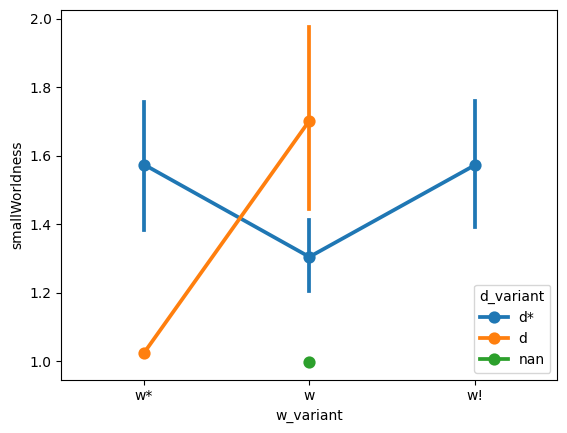

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='d_variant', data=final_df)

<Axes: xlabel='w_variant', ylabel='smallWorldness'>

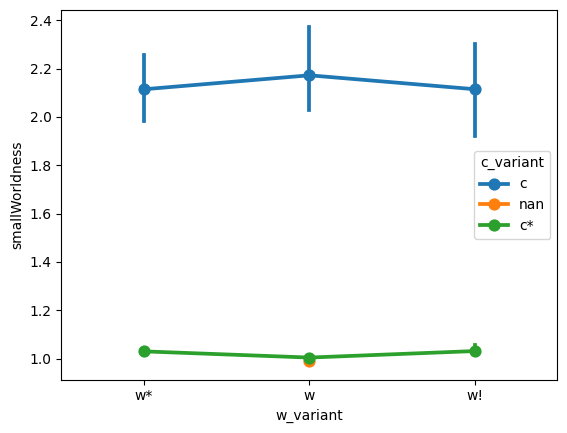

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='c_variant', data=final_df)

<Axes: xlabel='d_variant', ylabel='smallWorldness'>

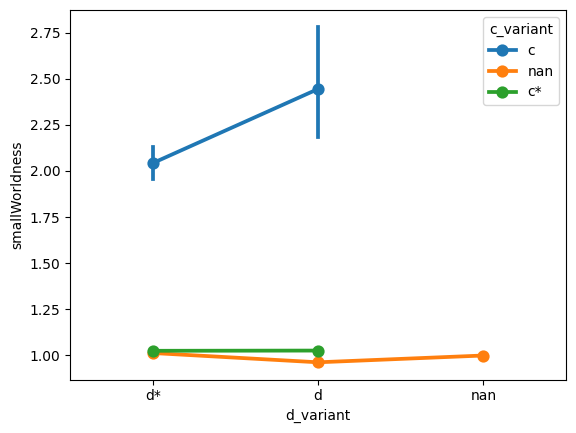

In [ ]:
sns.pointplot(x='d_variant', y='smallWorldness', hue='c_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=2.177 mean=2.445

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1.027 mean=1.025

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.9607 mean=0.961

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=8.417, p=0.0149
Group sizes & medians:
  w_variant=w          n=20   median=1.906 mean=1.899
  w_variant=w!         n=20   median=2.202 mean=2.114
  w_variant=w*         n=20   median=2.184 mean=2.114
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=119.0, p_raw=0.0294, p_adj=0.118, sig=no, Median: w 1.906 < w! 2.202
  w vs w*: U=96.0, p_raw=0.00512, p_adj=0.0307, sig=YES, Median: w 1.906 < w* 2.184
  w! vs w*: U=210.0, p_raw=0.797, p_adj=0.881, sig=no, Median: w! 2.202 > w* 2.184

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=7.344, p=0.0254
Group sizes & medians:


In [ ]:
anova_results = rank_based_anova(final_df, 'assortivity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),5.809397e-11,2.0,1.707924e-14,1.000000e+00
C(d_variant),1.831132e+05,1.0,1.076681e+02,2.098310e-19
C(c_variant),-3.426361e+05,1.0,-2.014655e+02,1.000000e+00
C(w_variant):C(d_variant),2.628341e+05,2.0,7.727150e+01,7.026946e-24
C(w_variant):C(c_variant),1.808556e+05,2.0,5.317035e+01,1.567498e-11
C(d_variant):C(c_variant),9.922937e+04,1.0,5.834556e+01,2.284975e-12
C(w_variant):C(d_variant):C(c_variant),1.984286e+04,2.0,5.833670e+00,3.622419e-03
Residual,2.585092e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=-0.2126 mean=-0.2433

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=-0.07318 mean=-0.07222

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=-0.01518 mean=-0.01525

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.384, p=2.8e-09
Group sizes & medians:
  w_variant=w          n=20   median=0.4103 mean=0.4246
  w_variant=w!         n=20   median=-0.03175 mean=-0.04023
  w_variant=w*         n=20   median=-0.04413 mean=-0.04106
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=400.0, p_raw=6.8e-08, p_adj=4.08e-07, sig=YES, Median: w 0.4103 > w! -0.03175
  w vs w*: U=400.0, p_raw=6.8e-08, p_adj=4.08e-07, sig=YES, Median: w 0.4103 > w* -0.04413
  w! vs w*: U=211.0, p_raw=0.776, p_adj=1, sig=no, Median: w! -0.03175 > w* -0.04413

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_v

In [ ]:
anova_results = rank_based_anova(final_df, 'accuracy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),1.484980e-09,2.0,6.479378e-13,1.000000e+00
C(d_variant),6.773835e+04,1.0,5.911223e+01,1.725207e-12
C(c_variant),1.113080e-10,1.0,9.713355e-14,9.999998e-01
C(w_variant):C(d_variant),1.182410e+05,2.0,5.159181e+01,7.930514e-18
C(w_variant):C(c_variant),7.350985e+04,2.0,3.207438e+01,7.208802e-08
C(d_variant):C(c_variant),6.556281e+03,1.0,5.721373e+00,1.798165e-02
C(w_variant):C(d_variant):C(c_variant),1.445152e+04,2.0,6.305599e+00,2.339916e-03
Residual,1.741810e+05,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='accuracy'>

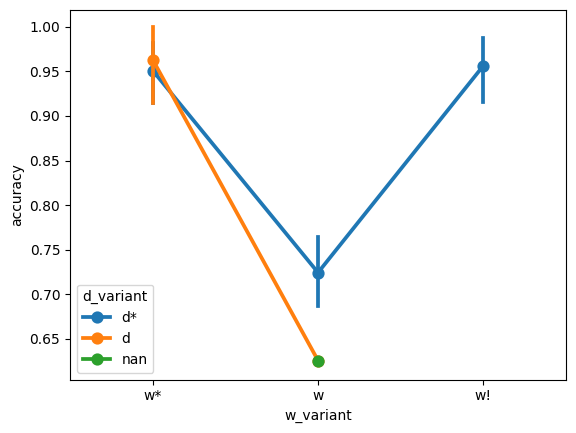

In [ ]:
sns.pointplot(x='w_variant', y='accuracy', hue='d_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.6246 mean=0.6238

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1 mean=0.9631

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.6275 mean=0.6275

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=38.227, p=5e-09
Group sizes & medians:
  w_variant=w          n=20   median=0.628 mean=0.6282
  w_variant=w!         n=20   median=1 mean=0.9496
  w_variant=w*         n=20   median=1 mean=0.9168
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=26.0, p_raw=1.23e-06, p_adj=6.16e-06, sig=YES, Median: w 0.628 < w! 1
  w vs w*: U=3.0, p_raw=6.36e-08, p_adj=3.81e-07, sig=YES, Median: w 0.628 < w* 1
  w! vs w*: U=226.0, p_raw=0.381, p_adj=0.761, sig=no, Median: w! 1 = w* 1

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=24.205, p=5.55e-06
Group sizes & medians:
  w_variant

In [ ]:
anova_results = rank_based_anova(final_df, 'entropy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),-5.096411e-11,2.0,-2.147134e-14,1.000000e+00
C(d_variant),7.239310e+04,1.0,6.099888e+01,8.679641e-13
C(c_variant),3.617635e-09,1.0,3.048242e-12,9.999986e-01
C(w_variant):C(d_variant),1.766249e+04,2.0,7.441260e+00,8.258250e-04
C(w_variant):C(c_variant),7.772323e+02,2.0,3.274504e-01,5.680096e-01
C(d_variant):C(c_variant),3.734675e+04,1.0,3.146860e+01,9.329635e-08
C(w_variant):C(d_variant):C(c_variant),1.736861e+04,2.0,7.317448e+00,9.244857e-04
Residual,1.803927e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.1085 mean=0.5988

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.02724 mean=0.02833

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.0554 mean=0.6271

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.439, p=2.73e-09
Group sizes & medians:
  w_variant=w          n=20   median=3.996 mean=3.935
  w_variant=w!         n=20   median=1.309 mean=1.258
  w_variant=w*         n=20   median=1.388 mean=1.354
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 3.996 > w! 1.309
  w vs w*: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 3.996 > w* 1.388
  w! vs w*: U=183.0, p_raw=0.655, p_adj=0.655, sig=no, Median: w! 1.309 < w* 1.388

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=0.792, p=0.673
Group 

In [ ]:
anova_results = rank_based_anova(final_df, 'modularity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),4.695552e-10,2.0,3.275339e-13,1.000000e+00
C(d_variant),9.851030e+03,1.0,1.374299e+01,2.931140e-04
C(c_variant),8.314454e-09,1.0,1.159934e-11,9.999973e-01
C(w_variant):C(d_variant),1.754957e+04,2.0,1.224154e+01,1.176734e-05
C(w_variant):C(c_variant),3.347555e+03,2.0,2.335056e+00,1.285687e-01
C(d_variant):C(c_variant),7.753295e+04,1.0,1.081648e+02,1.812308e-19
C(w_variant):C(d_variant):C(c_variant),1.403693e+04,2.0,9.791328e+00,1.000311e-04
Residual,1.089542e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.1324 mean=0.132

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.08989 mean=0.09062

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.08994 mean=0.08898

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=4.940, p=0.0846
Group sizes & medians:
  w_variant=w          n=20   median=0.5029 mean=0.4937
  w_variant=w!         n=20   median=0.4879 mean=0.4828
  w_variant=w*         n=20   median=0.4747 mean=0.4663

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=21.955, p=1.71e-05
Group sizes & medians:
  w_variant=w          n=20   median=0.1232 mean=0.1149
  w_variant=w!         n=20   median=0.08897 mean=0.09541
  w_variant=w*         n=20   median=0.09013 mean=0.09595
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=341.0, p_raw=0.000144, p_adj=0.000289, sig=YES,

In [ ]:
anova_results = rank_based_anova(final_df, 'loss')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),2.227616e-09,2.0,5.799820e-12,1.000000e+00
C(d_variant),2.597784e+03,1.0,1.352718e+01,3.256997e-04
C(c_variant),4.910276e+05,1.0,2.556879e+03,5.633475e-97
C(w_variant):C(d_variant),9.011908e+04,2.0,2.346340e+02,3.395508e-47
C(w_variant):C(c_variant),2.173153e+05,2.0,5.658023e+02,4.216635e-53
C(d_variant):C(c_variant),7.632026e+03,1.0,3.974149e+01,2.989068e-09
C(w_variant):C(d_variant):C(c_variant),3.625671e+04,2.0,9.439796e+01,2.241500e-27
Residual,2.919035e+04,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.01412 mean=0.0149

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.9906 mean=0.989

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.6483 mean=0.6487

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=33.352, p=5.72e-08
Group sizes & medians:
  w_variant=w          n=20   median=0.04574 mean=0.04446
  w_variant=w!         n=20   median=0.00167 mean=0.005575
  w_variant=w*         n=20   median=0.002337 mean=0.01132
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=392.0, p_raw=2.22e-07, p_adj=1.33e-06, sig=YES, Median: w 0.04574 > w! 0.00167
  w vs w*: U=373.0, p_raw=3.07e-06, p_adj=1.53e-05, sig=YES, Median: w 0.04574 > w* 0.002337
  w! vs w*: U=167.0, p_raw=0.379, p_adj=0.759, sig=no, Median: w! 0.00167 < w* 0.002337

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_vari

# The effect of number of neurons

In [ ]:
session, scan, field = 5, 3, 4

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_1 = f'/content/data/simu/{base}'
print(folder_name_1)

/content/data/simu/5_3_4_sttc-corr


In [ ]:
task1_folder_dir_neuron = f'{folder_name_1}/Task1/'
task1_folder_dir_neuron

'/content/data/simu/5_3_4_sttc-corr/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_neuron, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_neuron = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_neuron.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_neuron.to_csv("combined_dataset_1.csv", index=False)

print(final_df_neuron.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.777930    -0.173498    0.602954  3.141714   
1                  1      W*D*C  0.755859     0.150889    0.628134  3.036219   
2                  2      W*D*C  1.000000    -0.127765    0.645759  2.697506   
3                  3      W*D*C  1.000000    -0.098826    0.615256  2.659157   
4                  4      W*D*C  1.000000     0.336267    0.580071  2.900176   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.020549  0.917393             1.000000         0.651179  
1        1.521436  0.735113             0.738281         0.658513  
2        1.481063  0.046804             1.000000         0.043395  
3        1.688839  0.087450             1.000000         0.083395  
4        0.954364  0.088310             1.000000         0.080835  


In [ ]:
scaler = MinMaxScaler()
final_df_neuron["w_variant"] = final_df_neuron["model_name"].apply(classify_variant)
final_df_neuron["loss"] = scaler.fit_transform(final_df_neuron[["loss"]])
final_df_neuron['validation_loss'] = scaler.fit_transform(final_df_neuron[["validation_loss"]])

In [ ]:
final_df['neunum'] = 312
final_df_neuron['neunum'] = 70

In [ ]:
combined_df_neuron = pd.concat([final_df, final_df_neuron], ignore_index=True)

combined_df_neuron = combined_df_neuron.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_neuron.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,d_variant,c_variant,neunum
0,0,W,0.617188,-0.016950,0.085761,5.657654,0.997841,0.330169,0.618359,0.302073,w,False,sttc,nan,nan,312
1,0,W,0.622266,-0.040578,0.199427,0.050396,0.775444,0.060112,0.621875,0.055012,w,NaN,NaN,NaN,NaN,70
2,0,W!D*C,1.000000,0.000551,0.470566,0.739893,2.225924,0.001798,1.000000,0.001418,w!,False,sttc,d*,c,312
3,0,W!D*C,1.000000,0.098730,0.625760,2.837234,1.539100,0.002830,1.000000,0.002748,w!,NaN,NaN,NaN,NaN,70
4,0,W!D*C*,1.000000,-0.045075,0.092286,1.102208,1.019185,0.399504,1.000000,0.369016,w!,False,sttc,d*,c*,312


In [ ]:
def is_number_of_neurons_significantly_different(df, metric):
  res = kruskal(
    df.query("neunum == 312")[metric],
    df.query("neunum == 70")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
for metric in metrics:
  print(f'{metric} : {is_number_of_neurons_significantly_different(combined_df_neuron, metric)}')

accuracy : (True, np.float64(0.0002846325706938227))
assortivity : (False, np.float64(0.16244733515480206))
entropy : (True, np.float64(1.5364618460622285e-18))
loss : (False, np.float64(0.8784295498227916))
modularity : (True, np.float64(4.422846121062874e-27))
smallWorldness : (True, np.float64(7.206914343134141e-25))
validation_accuracy : (True, np.float64(4.781658610682675e-06))
validation_loss : (False, np.float64(0.29470620796808666))


# other

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def simple_effects_w_within_dc(df, metric, alpha=0.05, correction='holm'):
    """
    For each (d_variant, c_variant) cell:
      1) omnibus test across all levels of w_variant (Kruskal–Wallis)
      2) if significant and w has >2 levels, do pairwise Mann–Whitney U with Holm correction
    Prints a tidy summary and returns a dict of results.
    """
    results = {}
    cells = df[['d_variant','c_variant']].drop_duplicates().itertuples(index=False, name=None)

    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # Split by w levels
        groups = {w: g[metric].astype(float).values for w, g in sub.groupby('w_variant')}
        levels = list(groups.keys())

        # Omnibus Kruskal–Wallis across w levels (nonparametric k-sample)
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan  # only one w level; nothing to compare

        # Pairwise posthocs (only if >=3 levels and omnibus sig; if exactly 2 levels, we just do MWU)
        pairwise = []
        pairs = list(itertools.combinations(levels, 2))
        raw_ps = []
        stats_u = []
        extra = []

        if len(levels) == 2:
            w1, w2 = levels
            x, y = groups[w1], groups[w2]
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            pairwise = [(w1, w2, u, p)]
            raw_ps = [p]
            stats_u = [u]
            extra = [{
                "w1": w1, "w2": w2,
                "median_w1": np.median(x), "median_w2": np.median(y),
                "n_w1": len(x), "n_w2": len(y),
                "P(X>Y)": u/(len(x)*len(y))
            }]
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
        elif len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha:
            for (w1, w2) in pairs:
                x, y = groups[w1], groups[w2]
                u, p = mannwhitneyu(x, y, alternative='two-sided')
                pairwise.append((w1, w2, u, p))
                raw_ps.append(p)
                stats_u.append(u)
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
            # enrich
            extra = []
            for (idx, (w1, w2, u, p)) in enumerate(pairwise):
                x, y = groups[w1], groups[w2]
                extra.append({
                    "w1": w1, "w2": w2,
                    "median_w1": np.median(x), "median_w2": np.median(y),
                    "n_w1": len(x), "n_w2": len(y),
                    "P(X>Y)": u/(len(x)*len(y))
                })
        else:
            reject, p_adj = [], []

        # Print a compact summary
        print(f"\n=== d={d_val}, c={c_val} ===")
        print(f"Kruskal–Wallis across w levels: H={H:.3f}  p={p_omni if np.isnan(p_omni) else f'{p_omni:.3g}'}")
        if len(levels) >= 2:
            print("Group sizes & medians:")
            for w in levels:
                arr = groups[w]
                print(f"  w={w:<10} n={len(arr):<4} median={np.median(arr):.4g} mean={np.mean(arr):.4g}")
        if pairwise:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for i, (w1, w2, u, p) in enumerate(pairwise):
                padj = p_adj[i]
                sig = "YES" if (len(reject)>i and reject[i]) else "no"
                ex = extra[i]
                direction = ">" if ex["median_w1"] > ex["median_w2"] else "<" if ex["median_w1"] < ex["median_w2"] else "="
                print(f"  {w1} vs {w2}: U={u:.1f}, p_raw={p:.3g}, p_adj={padj:.3g}, sig={sig}, "
                      f"Median: {w1} {ex['median_w1']:.4g} {direction} {w2} {ex['median_w2']:.4g}, "
                      f"P(X>Y)={ex['P(X>Y)']:.2f}")

        results[(d_val, c_val)] = {
            "kruskal_H": H, "kruskal_p": p_omni,
            "levels": levels,
            "pairwise": pairwise,
            "p_adj": p_adj if pairwise else None,
            "details": extra
        }

    print("\nDone.")
    return results

# Usage:
# simple_results = simple_effects_w_within_dc(final_df, 'smallWorldness', alpha=0.05, correction='holm')
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def simple_effects_w_within_dc(df, metric, alpha=0.05, correction='holm'):
    """
    For each (d_variant, c_variant) cell:
      1) omnibus test across all levels of w_variant (Kruskal–Wallis)
      2) if significant and w has >2 levels, do pairwise Mann–Whitney U with Holm correction
    Prints a tidy summary and returns a dict of results.
    """
    results = {}
    cells = df[['d_variant','c_variant']].drop_duplicates().itertuples(index=False, name=None)

    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # Split by w levels
        groups = {w: g[metric].astype(float).values for w, g in sub.groupby('w_variant')}
        levels = list(groups.keys())

        # Omnibus Kruskal–Wallis across w levels (nonparametric k-sample)
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan  # only one w level; nothing to compare

        # Pairwise posthocs (only if >=3 levels and omnibus sig; if exactly 2 levels, we just do MWU)
        pairwise = []
        pairs = list(itertools.combinations(levels, 2))
        raw_ps = []
        stats_u = []
        extra = []

        if len(levels) == 2:
            w1, w2 = levels
            x, y = groups[w1], groups[w2]
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            pairwise = [(w1, w2, u, p)]
            raw_ps = [p]
            stats_u = [u]
            extra = [{
                "w1": w1, "w2": w2,
                "median_w1": np.median(x), "median_w2": np.median(y),
                "n_w1": len(x), "n_w2": len(y),
                "P(X>Y)": u/(len(x)*len(y))
            }]
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
        elif len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha:
            for (w1, w2) in pairs:
                x, y = groups[w1], groups[w2]
                u, p = mannwhitneyu(x, y, alternative='two-sided')
                pairwise.append((w1, w2, u, p))
                raw_ps.append(p)
                stats_u.append(u)
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
            # enrich
            extra = []
            for (idx, (w1, w2, u, p)) in enumerate(pairwise):
                x, y = groups[w1], groups[w2]
                extra.append({
                    "w1": w1, "w2": w2,
                    "median_w1": np.median(x), "median_w2": np.median(y),
                    "n_w1": len(x), "n_w2": len(y),
                    "P(X>Y)": u/(len(x)*len(y))
                })
        else:
            reject, p_adj = [], []

        # Print a compact summary
        print(f"\n=== d={d_val}, c={c_val} ===")
        print(f"Kruskal–Wallis across w levels: H={H:.3f}  p={p_omni if np.isnan(p_omni) else f'{p_omni:.3g}'}")
        if len(levels) >= 2:
            print("Group sizes & medians:")
            for w in levels:
                arr = groups[w]
                print(f"  w={w:<10} n={len(arr):<4} median={np.median(arr):.4g} mean={np.mean(arr):.4g}")
        if pairwise:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for i, (w1, w2, u, p) in enumerate(pairwise):
                padj = p_adj[i]
                sig = "YES" if (len(reject)>i and reject[i]) else "no"
                ex = extra[i]
                direction = ">" if ex["median_w1"] > ex["median_w2"] else "<" if ex["median_w1"] < ex["median_w2"] else "="
                print(f"  {w1} vs {w2}: U={u:.1f}, p_raw={p:.3g}, p_adj={padj:.3g}, sig={sig}, "
                      f"Median: {w1} {ex['median_w1']:.4g} {direction} {w2} {ex['median_w2']:.4g}, "
                      f"P(X>Y)={ex['P(X>Y)']:.2f}")

        results[(d_val, c_val)] = {
            "kruskal_H": H, "kruskal_p": p_omni,
            "levels": levels,
            "pairwise": pairwise,
            "p_adj": p_adj if pairwise else None,
            "details": extra
        }

    print("\nDone.")
    return results

# Usage:
simple_results = simple_effects_w_within_dc(final_df, 'accuracy', alpha=0.05, correction='holm')



=== d=d*, c=c ===
Kruskal–Wallis across w levels: H=38.227  p=5e-09
Group sizes & medians:
  w=w          n=20   median=0.628 mean=0.6282
  w=w!         n=20   median=1 mean=0.9496
  w=w*         n=20   median=1 mean=0.9168
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=26.0, p_raw=1.23e-06, p_adj=2.46e-06, sig=YES, Median: w 0.628 < w! 1, P(X>Y)=0.07
  w vs w*: U=3.0, p_raw=6.36e-08, p_adj=1.91e-07, sig=YES, Median: w 0.628 < w* 1, P(X>Y)=0.01
  w! vs w*: U=226.0, p_raw=0.381, p_adj=0.381, sig=no, Median: w! 1 = w* 1, P(X>Y)=0.56

=== d=d, c=c ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d*, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=nan, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d*, c=c* ===
Kruskal–Wallis across w levels: H=24.205  p=5.55e-06
Group sizes & medians:
  w=w          n=20   median=0.6302 mean=0.7575
  w=w!         n=20   median=1 mean=0.9631
  w=w*  

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def _vargha_delaney_A12(x, y):
    """Vargha–Delaney A12 = P(X>Y) + 0.5*P(X==Y). For MWU without ties, A12 ~ U/(n1*n2)."""
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    # Use ranks approach to handle ties properly
    allvals = np.concatenate([x, y])
    ranks = pd.Series(allvals).rank(method='average').to_numpy()
    rx = ranks[:n1].sum()
    # U for group X:
    U = rx - n1*(n1+1)/2
    A12 = U / (n1*n2)
    # With ties, A12 computed this way approximates P(X>Y); to incorporate ties:
    # A12_tie = A12 + 0.5*(1 - A12 - P(Y>X)) but we stick to standard MW mapping.
    return float(A12)

def _cliffs_delta(x, y):
    """Cliff's delta in O(n log n) via ranks (approx)."""
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    # brute force is O(n1*n2); for practical n this is fine
    greater = 0; less = 0
    for xi in x:
        greater += np.sum(xi > y)
        less    += np.sum(xi < y)
    delta = (greater - less) / (n1 * n2)
    return float(delta)

def simple_effects_w_within_dc_df(df, metric, alpha=0.05, correction='holm', mw_method='auto'):
    """
    Stratified simple-effects of w within each (d_variant, c_variant) cell.

    Returns a tidy DataFrame with:
      - one row for each cell's Kruskal–Wallis omnibus (k-sample)
      - one row per pairwise w comparison with Holm-adjusted p-values
    `correction` is applied GLOBALLY over all pairwise rows across all cells.
    """
    records_omni = []
    records_pairs = []

    # stable ordering of cells for reproducibility
    cells = (
        df[['d_variant','c_variant']]
        .dropna()
        .drop_duplicates()
        .sort_values(['d_variant','c_variant'])
        .itertuples(index=False, name=None)
    )

    # First pass: compute all raw results and collect raw p-values for global correction
    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # groups by w (sorted for stable printing)
        groups = {w: g[metric].astype(float).to_numpy()
                  for w, g in sub.groupby('w_variant')}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        # Omnibus
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        n_by_w = {w: len(groups[w]) for w in levels}
        med_by_w = {w: float(np.median(groups[w])) for w in levels}
        mean_by_w = {w: float(np.mean(groups[w])) for w in levels}

        records_omni.append({
            'd_variant': d_val,
            'c_variant': c_val,
            'metric': metric,
            'w_levels': tuple(levels),
            'kruskal_H': H,
            'kruskal_p': p_omni,
            'n_by_w': n_by_w,
            'median_by_w': med_by_w,
            'mean_by_w': mean_by_w
        })

        # Pairwise tests:
        pairs = list(itertools.combinations(levels, 2))
        # Strategy:
        # - if there are exactly 2 levels, always do a pairwise MWU (even if omnibus NaN)
        # - if >2 levels, only do pairwise if omnibus < alpha (common practice)
        do_pairs = False
        if len(levels) == 2:
            do_pairs = True
        elif len(levels) > 2 and (not np.isnan(p_omni)) and (p_omni < alpha):
            do_pairs = True

        if do_pairs:
            for w1, w2 in pairs:
                x, y = groups[w1], groups[w2]
                # Two-sided MWU. Use exact when small n and few ties (SciPy >=1.7 supports method kw)
                u, p_raw = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                A12 = _vargha_delaney_A12(x, y)
                delta = _cliffs_delta(x, y)
                rec = {
                    'd_variant': d_val,
                    'c_variant': c_val,
                    'metric': metric,
                    'w1': w1, 'w2': w2,
                    'n_w1': len(x), 'n_w2': len(y),
                    'median_w1': float(np.median(x)),
                    'median_w2': float(np.median(y)),
                    'mean_w1': float(np.mean(x)),
                    'mean_w2': float(np.mean(y)),
                    'U': float(u),
                    'p_raw': float(p_raw),
                    'A12': A12,            # ≈ P(X>Y)
                    'cliffs_delta': delta  # effect size in [-1,1]
                }
                records_pairs.append(rec)

    # Global multiplicity correction over all pairwise rows
    if len(records_pairs) > 0:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = float(p_adj[i])
            r['significant'] = bool(reject[i])
    else:
        p_adj = []

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # Pretty print (optional)
    for _, row in df_omni.iterrows():
        d_val, c_val = row['d_variant'], row['c_variant']
        H, p = row['kruskal_H'], row['kruskal_p']
        print(f"\n=== d={d_val}, c={c_val} ===")
        if len(row['w_levels']) >= 2:
            ptxt = "nan" if pd.isna(p) else f"{p:.3g}"
            print(f"Kruskal–Wallis across w: H={H:.3f}, p={ptxt}")
            print("Group sizes & medians:")
            for w in row['w_levels']:
                print(f"  w={w:<10} n={row['n_by_w'][w]:<4} median={row['median_by_w'][w]:.6g} mean={row['mean_by_w'][w]:.6g}")
        else:
            # There is only one w_variant in this (d, c)
            w = levels[0]
            arr = groups[w]
            print(f"Only one w level present: w={w}")
            print(f"  n={len(arr)}  median={np.median(arr):.4g}  mean={np.mean(arr):.4g}")
            # results[(d_val, c_val)] = {
            #     "kruskal_H": np.nan, "kruskal_p": np.nan,
            #     "levels": levels,
            #     "pairwise": [],
            #     "p_adj": None,
            #     "details": [{
            #         "w1": w,
            #         "n_w1": len(arr),
            #         "median_w1": np.median(arr),
            #         "mean_w1": np.mean(arr)
            #     }]
            # }
            continue
        # Show pairwise for this cell (if any)
        if not df_pairs.empty:
            sub_pairs = df_pairs.query("d_variant == @d_val and c_variant == @c_val")
            if not sub_pairs.empty:
                print("Pairwise Mann–Whitney (global Holm-corrected):")
                for _, r2 in sub_pairs.iterrows():
                    direction = ">" if r2['median_w1'] > r2['median_w2'] else "<" if r2['median_w1'] < r2['median_w2'] else "="
                    padj_txt = "nan" if pd.isna(r2['p_adj']) else f"{r2['p_adj']:.3g}"
                    print(f"  {r2['w1']} vs {r2['w2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={padj_txt}, "
                          f"sig={'YES' if r2.get('significant', False) else 'no'}, "
                          f"Median: {r2['w1']} {r2['median_w1']:.6g} {direction} {r2['w2']} {r2['median_w2']:.6g}, "
                          f"A12={r2['A12']:.3f}, Cliffδ={r2['cliffs_delta']:.3f}")

    print("\nDone.")
    return df_omni, df_pairs

# Example usage:
df_omni, df_pairs = simple_effects_w_within_dc_df(final_df, 'accuracy', alpha=0.05, correction='holm', mw_method='auto')
# Now you can sort/filter df_pairs, make plots, etc.



=== d=d, c=c ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d, c=c* ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d, c=nan ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d*, c=c ===
Kruskal–Wallis across w: H=38.227, p=5e-09
Group sizes & medians:
  w=w          n=20   median=0.628027 mean=0.628223
  w=w!         n=20   median=1 mean=0.949609
  w=w*         n=20   median=1 mean=0.916777
Pairwise Mann–Whitney (global Holm-corrected):
  w vs w!: U=26.0, p_raw=1.23e-06, p_adj=6.16e-06, sig=YES, Median: w 0.628027 < w! 1, A12=0.065, Cliffδ=-0.870
  w vs w*: U=3.0, p_raw=6.36e-08, p_adj=3.81e-07, sig=YES, Median: w 0.628027 < w* 1, A12=0.007, Cliffδ=-0.985
  w! vs w*: U=226.0, p_raw=0.381, p_adj=0.761, sig=no, Median: w! 1 = w* 1, A12=0.565, Cliffδ=0.130

=== d=d*, c=c* ===
Kruskal–Wallis across w: H=24.205, p=5.55e-06
Group sizes & medians:
  w=w          n=20   median=0.630176 mean=0.75751
  w=w!     

# Better Code

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def _fmt_p(p):
    # nice compact formatting for p-values
    if pd.isna(p):
        return "-"
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.3f}"

def _fmt_float(x, digits=3):
    if pd.isna(x):
        return "-"
    return f"{x:.{digits}f}"

def simple_effects_generic(
    df, metric, focus_factor, within, alpha=0.05, correction='holm',
    mw_method='auto', save_summary_csv=None
):
    """
    Generic simple-effects tester that ALSO returns a publication-ready summary DataFrame.

    Creates three outputs:
      - df_omni: one row per 'cell' (unique combo of `within` factors) with omnibus KW results
      - df_pairs: pairwise Mann–Whitney results (Holm-corrected across ALL pairs)
      - df_summary: a compact table with columns:
            ['Comparison','Condition (fixed variants)','Test','H / U Statistic','df',
             'p-value','Post hoc significant pairs (Holm-corrected)',
             'Direction (Median comparison)','Metric']

    Parameters are the same as your original, with one addition:
      - save_summary_csv: optional path to save df_summary as CSV.

    Returns:
      df_omni, df_pairs, df_summary
    """

    records_omni = []
    records_pairs = []

    # All unique cells (combinations of the "within" factors)
    cells = (
        df[within].dropna().drop_duplicates().sort_values(within)
        .itertuples(index=False, name=None)
    )

    for combo in cells:
        # Filter for current cell
        sub = df.query(
            " and ".join([f"{col} == @{col}" for col in within]),
            local_dict=dict(zip(within, combo))
        )[[focus_factor, metric]].dropna()

        if sub.empty:
            continue

        # Group by focus factor
        groups = {g: vals[metric].astype(float).to_numpy()
                  for g, vals in sub.groupby(focus_factor)}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        # Omnibus KW (if we have >= 2 levels)
        if len(levels) >= 2:
            samples = [groups[l] for l in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        # Record omnibus
        records_omni.append({
            **dict(zip(within, combo)),
            'focus_factor': focus_factor,
            'levels': levels,
            'H': H,
            'p_omni': p_omni,
            'n_by_level': {l: len(groups[l]) for l in levels},
            'median_by_level': {l: float(np.median(groups[l])) for l in levels},
            'mean_by_level': {l: float(np.mean(groups[l])) for l in levels},
        })

        # Pairwise if exactly two levels OR significant omnibus
        do_pairs = (len(levels) == 2) or (len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha)
        if do_pairs:
            for (l1, l2) in itertools.combinations(levels, 2):
                x, y = groups[l1], groups[l2]
                u, p = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                records_pairs.append({
                    **dict(zip(within, combo)),
                    'focus_factor': focus_factor,
                    'l1': l1, 'l2': l2,
                    'U': float(u), 'p_raw': float(p),
                    'n1': int(len(x)), 'n2': int(len(y)),
                    'median1': float(np.median(x)), 'median2': float(np.median(y)),
                    'mean1': float(np.mean(x)), 'mean2': float(np.mean(y))
                })

    # Holm correction across ALL pairwise tests
    if records_pairs:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = float(p_adj[i])
            r['significant'] = bool(reject[i])

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # ---------- Build the publication-style summary table ----------
    summary_rows = []
    comparison_label = f"{focus_factor} variants"

    for _, row in df_omni.iterrows():
        # Condition string (fixed factors)
        cond = ", ".join([f"{k}={row[k]}" for k in within])

        # Determine df for KW
        k_levels = len(row['levels'])
        df_kw = k_levels - 1 if k_levels >= 2 else np.nan

        # Find matching pairwise rows (for this exact cell)
        if not df_pairs.empty:
            mask = np.ones(len(df_pairs), dtype=bool)
            for k in within:
                mask &= (df_pairs[k] == row[k])
            sub_pairs = df_pairs[mask]
        else:
            sub_pairs = df_pairs  # empty

        # Build "post hoc significant pairs" and "direction" strings
        posthoc_bits = []
        direction_bits = []
        if not sub_pairs.empty:
            for _, r2 in sub_pairs.iterrows():
                # only list significant pairs
                if r2.get('significant', False):
                    # direction by medians
                    if r2['median1'] > r2['median2']:
                        dir_symbol = ">"
                        lhs, rhs = r2['l1'], r2['l2']
                        lhs_med, rhs_med = r2['median1'], r2['median2']
                    elif r2['median1'] < r2['median2']:
                        dir_symbol = "<"
                        # flip for a ">" phrasing in direction column
                        lhs, rhs = r2['l2'], r2['l1']
                        lhs_med, rhs_med = r2['median2'], r2['median1']
                    else:
                        dir_symbol = "="
                        lhs, rhs = r2['l1'], r2['l2']
                        lhs_med, rhs_med = r2['median1'], r2['median2']

                    posthoc_bits.append(f"{r2['l1']} vs {r2['l2']} (U={_fmt_float(r2['U'],1)}, p_adj={_fmt_p(r2['p_adj'])})")
                    if dir_symbol == "=":
                        direction_bits.append(f"{r2['l1']} ({_fmt_float(r2['median1'])}) = {r2['l2']} ({_fmt_float(r2['median2'])})")
                    else:
                        direction_bits.append(f"{lhs} ({_fmt_float(lhs_med)}) > {rhs} ({_fmt_float(rhs_med)})")
        # If no significant pairs or no pairs tested
        if not posthoc_bits:
            posthoc_bits = ["none"]
        if not direction_bits:
            # If only one level present, reflect that; else no differences
            if k_levels < 2:
                only = row['levels'][0]
                n_only = row['n_by_level'][only]
                direction_bits = [f"only {focus_factor}={only} (n={n_only})"]
            else:
                direction_bits = ["—"]

        # Compose the summary row
        if k_levels >= 2:
            test_name = "Kruskal–Wallis (rank-based ANOVA)"
            stat_str = f"H={_fmt_float(row['H'])}"
            df_str = f"{int(df_kw)}"
            p_str = _fmt_p(row['p_omni'])
        else:
          continue
            # test_name = "—"
            # stat_str = "—"
            # df_str = "—"
            # p_str = "—"

        summary_rows.append({
            "Comparison": comparison_label,
            "Condition (fixed variants)": cond,
            "Test": test_name,
            "H / U Statistic": stat_str,
            "df": df_str,
            "p-value": p_str,
            "Post hoc significant pairs (Holm-corrected)": "; ".join(posthoc_bits),
            "Direction (Median comparison)": "; ".join(direction_bits),
            "Metric": metric,
        })

    df_summary = pd.DataFrame(summary_rows, columns=[
        "Comparison","Condition (fixed variants)","Test","H / U Statistic","df","p-value",
        "Post hoc significant pairs (Holm-corrected)","Direction (Median comparison)","Metric"
    ])

    # Optional save
    if save_summary_csv is not None:
        df_summary.to_csv(save_summary_csv, index=False)

    # --------- (Optional) Pretty print, same as before ----------
    for _, row in df_omni.iterrows():
        cell_desc = ", ".join([f"{k}={row[k]}" for k in within])
        print(f"\n=== {cell_desc} ===")
        if len(row['levels']) >= 2:
            print(f"Kruskal–Wallis across {focus_factor}: H={row['H']:.3f}, p={row['p_omni']:.3g}")
            print("Group sizes & medians:")
            for l in row['levels']:
                print(f"  {focus_factor}={l:<10} n={row['n_by_level'][l]:<4} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
        else:
            l = row['levels'][0]
            print(f"Only one {focus_factor} level present: {l}")
            print(f"  n={row['n_by_level'][l]} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
            continue

        if not df_pairs.empty:
            mask = np.ones(len(df_pairs), dtype=bool)
            for k in within:
                mask &= (df_pairs[k] == row[k])
            sub_pairs = df_pairs[mask]
        else:
            sub_pairs = df_pairs

        if not sub_pairs.empty:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for _, r2 in sub_pairs.iterrows():
                direction = ">" if r2['median1'] > r2['median2'] else "<" if r2['median1'] < r2['median2'] else "="
                print(f"  {r2['l1']} vs {r2['l2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={r2['p_adj']:.3g}, sig={'YES' if r2['significant'] else 'no'}, "
                      f"Median: {r2['l1']} {r2['median1']:.4g} {direction} {r2['l2']} {r2['median2']:.4g}")

    print("\nDone.")
    return df_omni, df_pairs, df_summary


In [ ]:
# Example: effect of W, conditioning on D and C, for the "smallWorldness" metric
df_omni, df_pairs, df_sum = simple_effects_generic(
    final_df, metric="smallWorldness",
    focus_factor="w_variant",
    within=["d_variant","c_variant"],
    save_summary_csv="smallworldness_w_summary.csv"  # optional
)

# View the concise summary table
df_sum.head(7)



=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=2.177 mean=2.445

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1.027 mean=1.025

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.9607 mean=0.961

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=8.417, p=0.0149
Group sizes & medians:
  w_variant=w          n=20   median=1.906 mean=1.899
  w_variant=w!         n=20   median=2.202 mean=2.114
  w_variant=w*         n=20   median=2.184 mean=2.114
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=119.0, p_raw=0.0294, p_adj=0.118, sig=no, Median: w 1.906 < w! 2.202
  w vs w*: U=96.0, p_raw=0.00512, p_adj=0.0307, sig=YES, Median: w 1.906 < w* 2.184
  w! vs w*: U=210.0, p_raw=0.797, p_adj=0.881, sig=no, Median: w! 2.202 > w* 2.184

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=7.344, p=0.0254
Group sizes & medians:
  w_variant=w         

,Comparison,Condition (fixed variants),Test,H / U Statistic,df,p-value,Post hoc significant pairs (Holm-corrected),Direction (Median comparison),Metric
0,w_variant variants,"d_variant=d*, c_variant=c",Kruskal–Wallis (rank-based ANOVA),H=8.417,2,0.015,"w vs w* (U=96.0, p_adj=0.031)",w* (2.184) > w (1.906),smallWorldness
1,w_variant variants,"d_variant=d*, c_variant=c*",Kruskal–Wallis (rank-based ANOVA),H=7.344,2,0.025,none,—,smallWorldness


In [ ]:
df_sum.shape

(2, 9)